In [1]:
# Core Python imports
import os
from pathlib import Path

# Scientific standard imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# PyEarthTools imports including NCI cached data
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt

my_site = 'site_archive_nci'  # set this to 'site_archive_nci', 'site_archive_jasmin' or 'site_archive_met_office'
import importlib
_ = importlib.import_module(my_site)

import warnings
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for join",category=FutureWarning)
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for compat",category=FutureWarning)
warnings.filterwarnings("ignore",message="Data requested at a higher resolution than available")
warnings.filterwarnings("ignore",message="Importing `spectral_angle_mapper` from `torchmetrics.functional`",category=FutureWarning)
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None",category=FutureWarning)
warnings.filterwarnings("ignore",message="IndexWarning: Data requested at a higher resolution than available. minute > hour",)

In [2]:
# We specify the date, hour, and minute for querying data
date = '20200105T0000'
start_date = '20200101T0000'
end_date = '20210101T0000'
bar_timestep = "1 hour" 
save_dir = Path("/scratch/er8/cd3022/CPDiT/stats/")

sat_mean_path = save_dir / "mean_sat.npy"
sat_std_path = save_dir / "std_sat.npy"
bar_mean_path = save_dir / "mean_bar.npy"
bar_std_path = save_dir / "std_bar.npy"

iterator = petpipe.iterators.DateRange(start_date, end_date, interval=bar_timestep)

# Set up pipelines

In [22]:
himawar_vars = [
    'surface_global_irradiance',
    'solar_elevation'
]
himawari = petdata.archive.Himawari(himawar_vars)

sat_pipe = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  #
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-32, -31, 148, 149),
    petpipe.operations.xarray.conversion.ToNumpy(),
    iterator=iterator,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

In [4]:
barra_convective_vars = [
    "RH24mean"
]
barra_conv = petdata.archive.BARRA_V2(barra_convective_vars, domain_id='AUST-11', frequency='1hr')

bar_pipe = petpipe.Pipeline(
    barra_conv,
    petdata.transforms.coordinates.Drop("crs"),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  #
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-33, -30, 148, 150),
    petpipe.operations.xarray.conversion.ToNumpy(),
    iterator=iterator,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

In [23]:
# combining means that times when there is no himawari data (i.e. night) the iterator will also skip those times for BARRA,
# so those BARRA times 
full_pipe = petpipe.Pipeline(
    (sat_pipe, bar_pipe),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
    iterator=iterator,
)

# Calculate normalisation stats

In [6]:
compute = False # takes about 30 mins
if compute:
    # Collect years worth of samples
    ss = []
    bs = []
    for sat_sample, bar_sample in full_pipe:
        ss.append(sat_sample)
        bs.append(bar_sample)
    
    sat_samples = np.stack(ss)
    bar_samples = np.stack(bs)
    
    # Calculate mean and std for each variable, stored in axis(1)
    sat_mean = np.nanmean(sat_samples, axis=(0,2,3,4))
    sat_std = np.nanstd(sat_samples, axis=(0,2,3,4))
    bar_mean = np.nanmean(bar_samples, axis=(0,2,3,4))
    bar_std = np.nanstd(bar_samples, axis=(0,2,3,4))
    
    # save stats to be used in petpipe normalisation
    np.save(sat_mean_path, sat_mean)
    np.save(sat_std_path, sat_std)
    np.save(bar_mean_path, bar_mean)
    np.save(bar_std_path, bar_std)

# Test the Stats

In [24]:
bar_normaliser = petpipe.operations.numpy.normalisation.Deviation(
    mean=bar_mean_path,
    deviation=bar_std_path,
    expand=True
)

sat_normaliser = petpipe.operations.numpy.normalisation.Deviation(
    mean=sat_mean_path,
    deviation=sat_std_path,
    expand=True
)

bar_pipe_normed = petpipe.Pipeline(
    bar_pipe,
    bar_normaliser,
)

sat_pipe_normed = petpipe.Pipeline(
    sat_pipe,
    sat_normaliser,
)

## BARRA

(array([0.08495535, 0.05013131, 0.06486456, 0.07186763, 0.07971261,
        0.09203496, 0.09383356, 0.10979139, 0.1387604 , 0.14606962,
        0.14197493, 0.14928415, 0.15092968, 0.15743527, 0.16256321,
        0.17595707, 0.17400539, 0.17358444, 0.17737299, 0.19214451,
        0.20959479, 0.25360319, 0.29692277, 0.34031888, 0.38991443,
        0.45994519, 0.50873712, 0.53563964, 0.55083211, 0.56453211,
        0.56966005, 0.56460865, 0.57046368, 0.56441731, 0.54685222,
        0.54214523, 0.53521869, 0.52833042, 0.49534325, 0.46710134,
        0.43832367, 0.39519544, 0.33538228, 0.28601634, 0.22903503,
        0.19279506, 0.16688751, 0.12035341, 0.07607713, 0.02812711]),
 array([-1.40227197, -1.33258384, -1.26289572, -1.19320759, -1.12351947,
        -1.05383134, -0.98414322, -0.91445509, -0.84476697, -0.77507884,
        -0.70539072, -0.63570259, -0.56601447, -0.49632634, -0.42663822,
        -0.35695009, -0.28726197, -0.21757384, -0.14788572, -0.07819759,
        -0.00850947,  0.06

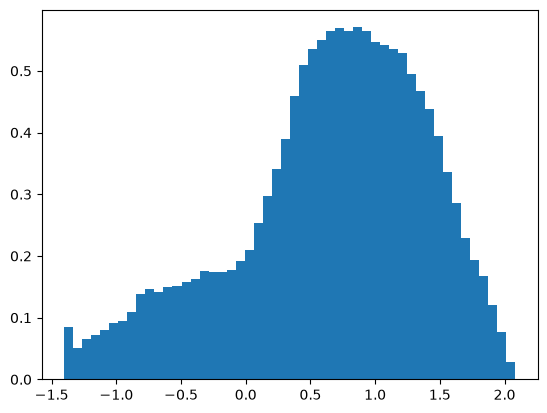

In [25]:
bar_normed_sample = bar_pipe_normed["2020-01"]

flat_bar = (bar_normed_sample).ravel()
plt.hist(flat_bar, bins=50, density=True)

In [26]:
bar_normed_sample.shape

(1, 744, 28, 18)

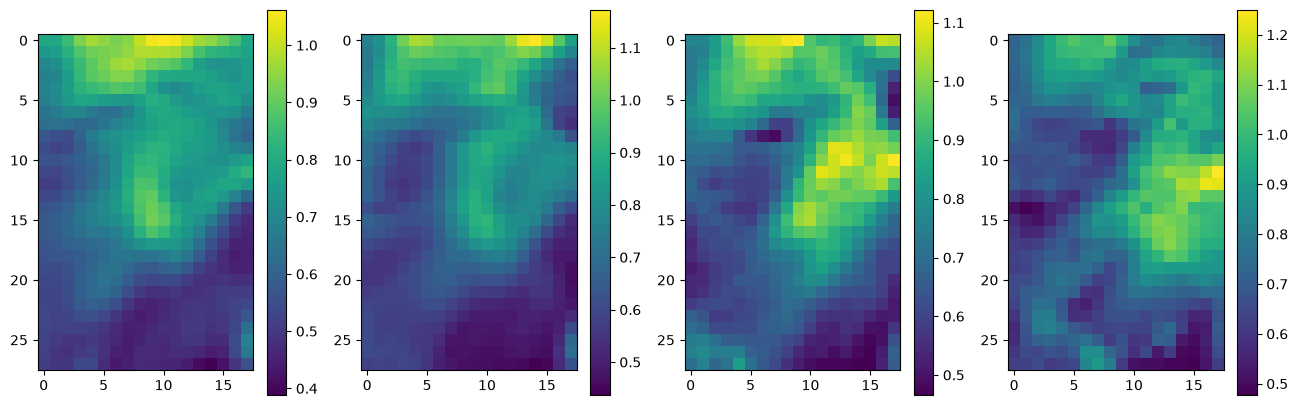

In [27]:
nrows = 1
ncols = 4
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*5))
for i in range(ncols):
    im = ax[i].imshow(bar_normed_sample[0,i,:,:])
    fig.colorbar(im, ax=ax[i])

## Himawari

/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/operations/index_routines.py:209: IndexWarning: Unable to subset on time dimension, returning all timesteps for validation. For request: 2020-01-05T00:00 -> 2020-01-06T00:00 @ 0 days 00:10:00
  warnings.warn(


(array([0.24004137, 0.18196423, 0.21554514, 0.2041352 , 0.14292168,
        0.18683103, 0.20797457, 0.16774236, 0.27519047, 0.287736  ,
        0.30677059, 0.3167205 , 0.32039763, 0.35149107, 0.31423302,
        0.32007318, 0.29860519, 0.29222427, 0.29200797, 0.28146324,
        0.28130101, 0.28130101, 0.28130101, 0.28130101, 0.28130101,
        0.28130101, 0.2855189 , 0.2800032 , 0.2926028 , 0.2782187 ,
        0.27713719, 0.29308948, 0.27627198, 0.27643421, 0.2923865 ,
        0.27654236, 0.29319763, 0.2773535 , 0.27848908, 0.29644216,
        0.28184177, 0.28459962, 0.30471572, 0.29346801, 0.3222362 ,
        0.31969465, 0.33840479, 0.34673243, 0.28011135, 0.70898454]),
 array([-1.43222454, -1.3625204 , -1.29281627, -1.22311214, -1.15340801,
        -1.08370387, -1.01399974, -0.94429561, -0.87459147, -0.80488734,
        -0.73518321, -0.66547907, -0.59577494, -0.52607081, -0.45636667,
        -0.38666254, -0.31695841, -0.24725427, -0.17755014, -0.10784601,
        -0.03814187,  0.03

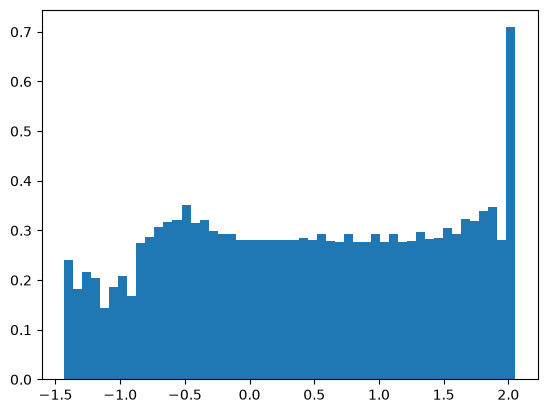

In [32]:
sat_normed_samples = sat_pipe_normed["20200105"]

flat_sat_v1 = (sat_normed_samples[0,:,:,:]).ravel()
plt.hist(flat_sat_v1, bins=50, density=True)

(array([0.69429839, 0.33703197, 0.24876468, 0.25828677, 0.25177165,
        0.1770984 , 0.21625174, 0.26022878, 0.1386968 , 0.26442601,
        0.20378532, 0.15780363, 0.27018939, 0.12879884, 0.25377631,
        0.21499883, 0.17014477, 0.25872529, 0.11138343, 0.30483226,
        0.18593139, 0.21105218, 0.29299229, 0.14608895, 0.33790901,
        0.24375305, 0.17828866, 0.32945189, 0.28591337, 0.16732572,
        0.30182529, 0.26837267, 0.13205639, 0.26179491, 0.25333779,
        0.1386968 , 0.11652035, 0.22984578, 0.23479476, 0.24250014,
        0.23554651, 0.18906366, 0.32137064, 0.34505058, 0.35463532,
        0.46276119, 0.52239956, 1.0241888 , 0.69768124, 0.01735276]),
 array([-1.39171547e+00, -1.31845430e+00, -1.24519313e+00, -1.17193195e+00,
        -1.09867078e+00, -1.02540960e+00, -9.52148429e-01, -8.78887255e-01,
        -8.05626081e-01, -7.32364907e-01, -6.59103733e-01, -5.85842559e-01,
        -5.12581385e-01, -4.39320211e-01, -3.66059037e-01, -2.92797863e-01,
        -2.195

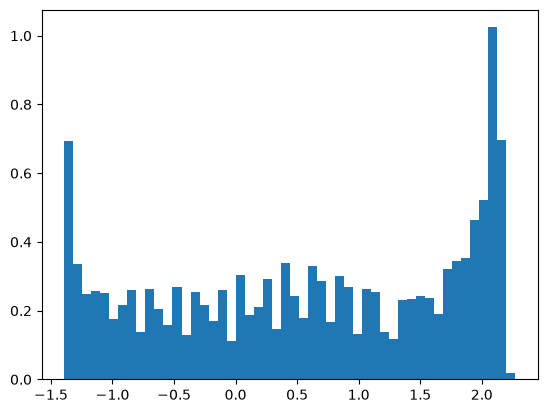

In [33]:
flat_sat_v2 = (sat_normed_samples[1,:,:,:]).ravel()
plt.hist(flat_sat_v2, bins=50, density=True)

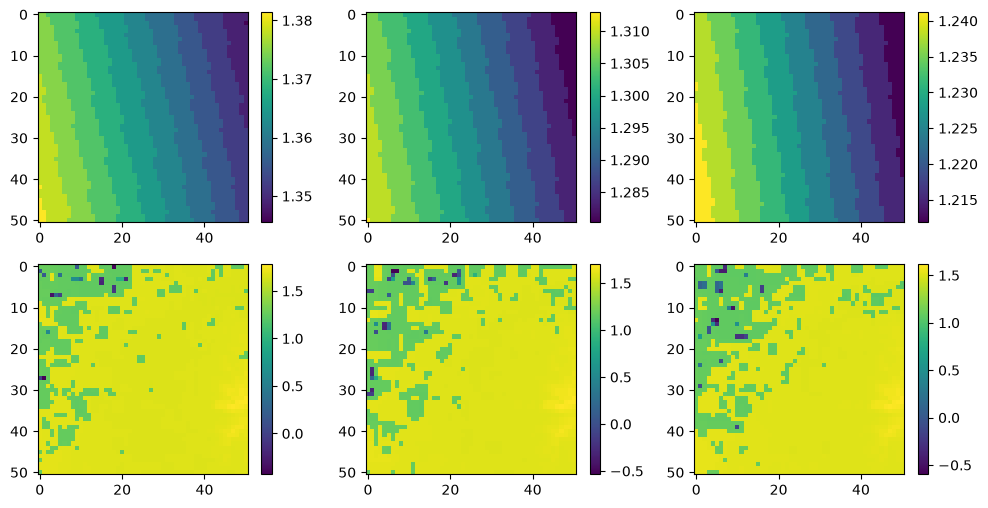

In [41]:
nrows = sat_normed_samples.shape[0]
ncols = 3 # num times to show
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3))
for i in range (nrows):
    for j in range(ncols):
        im = ax[i,j].imshow(sat_normed_samples[i,j+25,:,:])
        fig.colorbar(im, ax=ax[i,j])